<a href="https://colab.research.google.com/github/marcelagrg/challenge-telecomx-parte2/blob/main/Challenge_TelecomX_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extração (coleta)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/dados_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


#🛠️ Pre processamento

## 1️⃣ Remover colunas irrelevantes

In [ ]:
df = df.drop(columns=['CustomerID'])

##2️⃣ Transformar 'No internet service' para 'No'

In [ ]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace( 'No internet service', 'No')

In [ ]:
df.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [ ]:
for col in df.columns:
    print(col, df[col].unique())

Churn ['No' 'Yes']
Gender ['Female' 'Male']
SeniorCitizen ['No' 'Yes']
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
Tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
PhoneService ['Yes' 'No']
MultipleLines ['No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['Yes' 'No']
StreamingTV ['Yes' 'No']
StreamingMovies ['No' 'Yes']
Contract ['One year' 'Month-to-month' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
ChargesDaily [2.19 2.   2.46 3.27 2.8  2.31 3.66 2.82 1.61 3.02 1.51 3.89 2.3  3.38
 1.5  3.19 2.04 2.4  2.09 0.84 3.14 2.79 0.66 0.68 1.02 3.46 0.65 3.04
 3.86 1.31 2.99 3.16 2.52 1.64 2.61 0.85 2.05 2.84 1.7

##3️⃣ Transformar variáveis categóricas em formato numérico

###🔹Codificação binária

In [ ]:
colunas_binarias = ['Partner', 'SeniorCitizen', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

In [ ]:
df[colunas_binarias] = df[colunas_binarias].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_9121/3849265487.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colunas_binarias] = df[colunas_binarias].replace({'Yes': 1, 'No': 0})


In [ ]:
df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})

/tmp/ipykernel_9121/3911945517.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})


###🔹One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
variaveis_categoricas = ['InternetService','Contract','PaymentMethod']

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[variaveis_categoricas])

df_encoded = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(variaveis_categoricas)
)

In [ ]:
df_numerico = df.drop(columns=variaveis_categoricas)

df_final = pd.concat([df_numerico, df_encoded], axis=1)

In [ ]:
for col in df_final.columns:
    print(col, df_final[col].unique())

Churn [0 1]
Gender [1 0]
SeniorCitizen [0 1]
Partner [1 0]
Dependents [1 0]
Tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
PhoneService [1 0]
MultipleLines [0 1]
OnlineSecurity [0 1]
OnlineBackup [1 0]
DeviceProtection [0 1]
TechSupport [1 0]
StreamingTV [1 0]
StreamingMovies [0 1]
PaperlessBilling [1 0]
ChargesDaily [2.19 2.   2.46 3.27 2.8  2.31 3.66 2.82 1.61 3.02 1.51 3.89 2.3  3.38
 1.5  3.19 2.04 2.4  2.09 0.84 3.14 2.79 0.66 0.68 1.02 3.46 0.65 3.04
 3.86 1.31 2.99 3.16 2.52 1.64 2.61 0.85 2.05 2.84 1.72 3.31 1.48 2.71
 3.33 3.05 3.48 3.17 1.68 2.15 3.49 3.65 2.38 3.87 3.32 3.13 3.03 2.81
 1.94 3.58 3.71 1.34 2.86 1.18 2.94 1.53 2.98 2.88 2.49 2.67 3.01 2.36
 1.81 3.83 2.9  2.91 3.6  3.88 2.97 2.48 0.67 1.17 3.52 2.51 3.41 3.85
 0.64 3.82 3.5  1.93 3.35 2.83 1.63 1.57 1.98 2.32 1.2  1.89 2.53 2.64


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7043 non-null   int64  
 1   Gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   Tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   MultipleLines                          7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  Tech

##4️⃣ Verificação da Proporção de Evasão

In [ ]:
df_final['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
df_final['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537



Clientes ativos: 73,4%

Clientes que cancelaram: 26,5%

Conclusão: **há um desequílibrio entre as classes**, o que pode impactar modelos preditivos e a análise de resultados.


#🎯 Correlação e Seleção de Variáveis

##1️⃣ Correlação entre variáveis

In [ ]:
correlacao = df_final.corr()

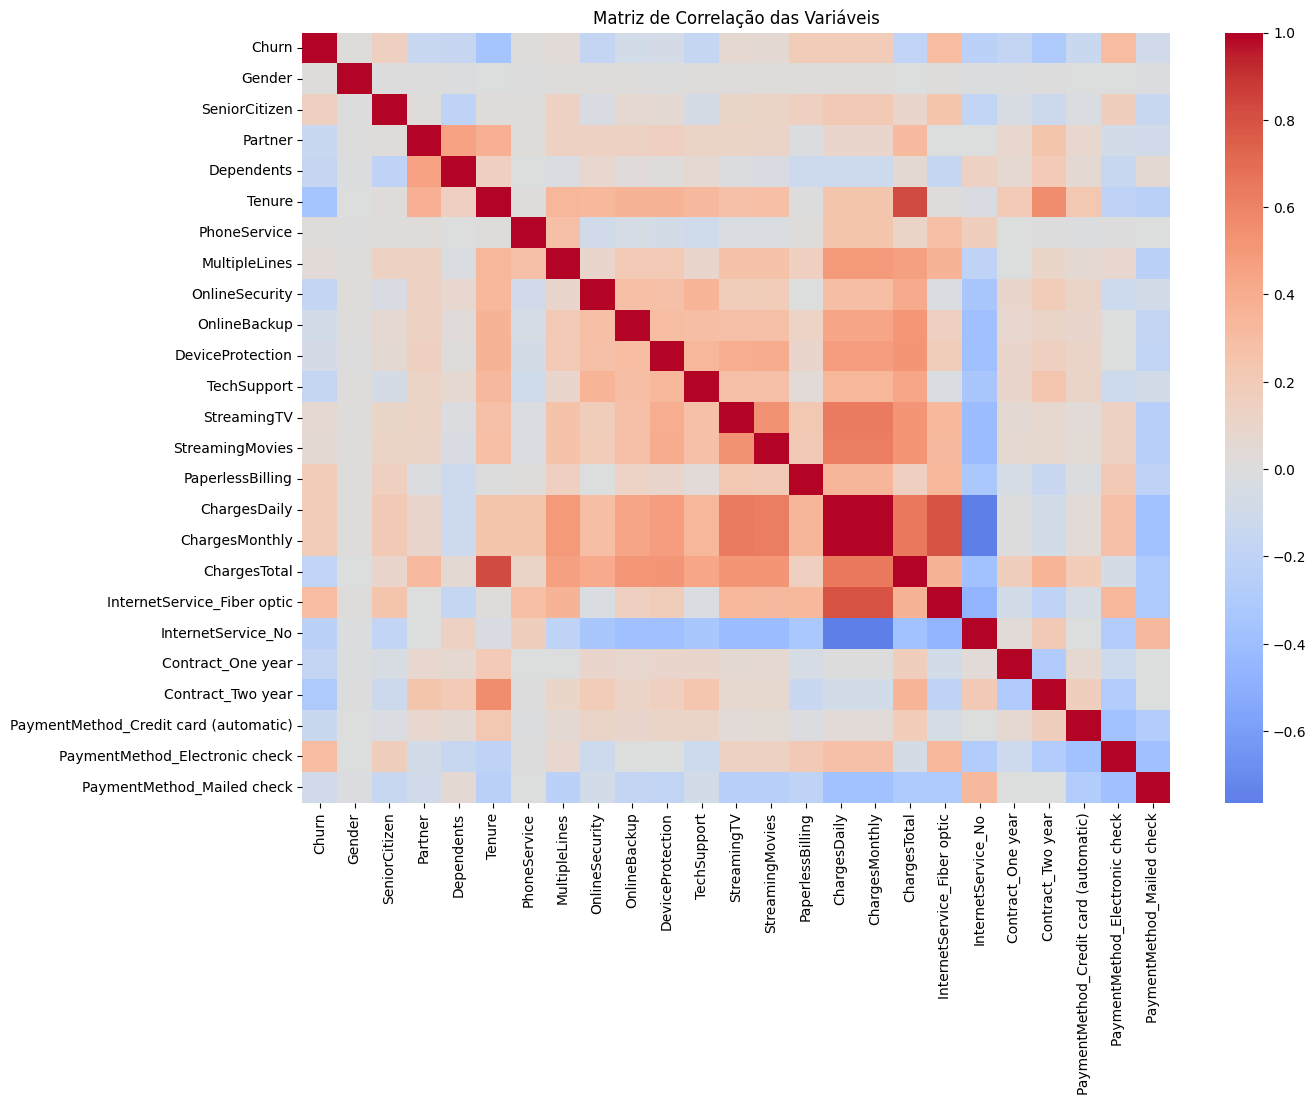

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(correlacao, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

*Correlação das variáveis com o Churn*

In [ ]:
correlacao_cancelamento = correlacao['Churn'].sort_values(ascending=False)
print(correlacao_cancelamento)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
ChargesDaily                             0.193412
ChargesMonthly                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV                              0.063228
StreamingMovies                          0.061382
MultipleLines                            0.040102
PhoneService                             0.011942
Gender                                   0.008612
DeviceProtection                        -0.066160
OnlineBackup                            -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport                             -0.164674
OnlineSecurity                          -0.171226


##2️⃣ Análises Direcionadas

###🔹Tempo de contrato × Evasão

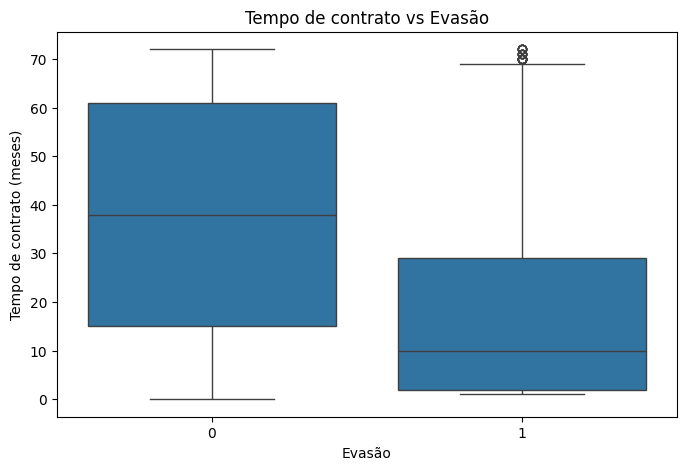

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Tenure', data=df_final)
plt.title('Tempo de contrato vs Evasão')
plt.xlabel('Evasão')
plt.ylabel('Tempo de contrato (meses)')
plt.show()

###2️⃣ Total gasto × Evasão

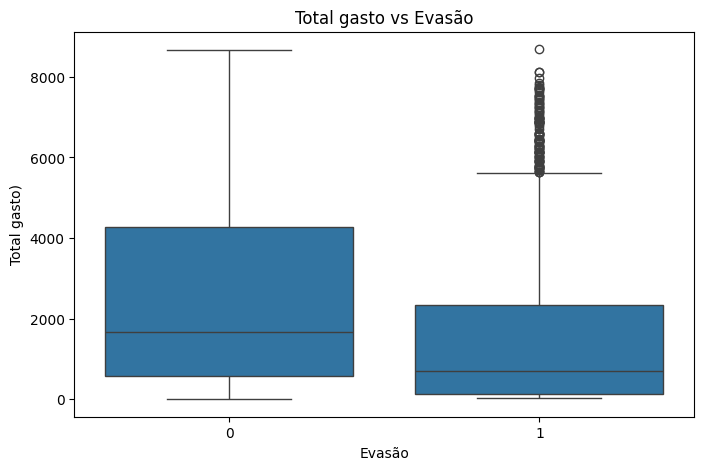

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='ChargesTotal', data=df_final)
plt.title('Total gasto vs Evasão')
plt.xlabel('Evasão')
plt.ylabel('Total gasto)')
plt.show()

###Tempo de contrato × Total gasto

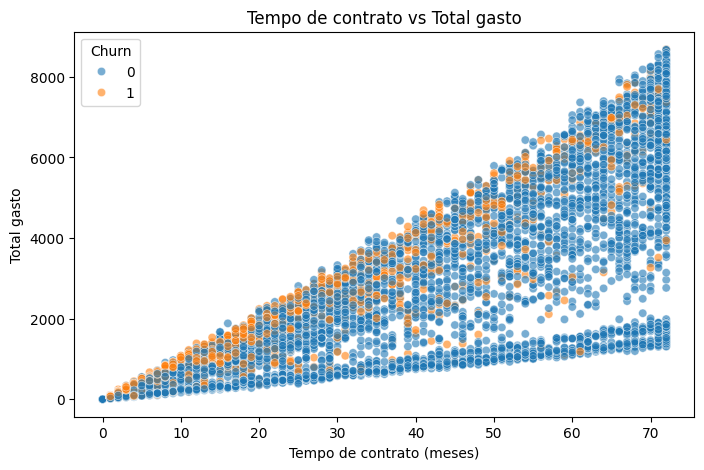

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Tenure',
    y='ChargesTotal',
    hue='Churn',
    data=df_final,
    alpha=0.6
)

plt.title('Tempo de contrato vs Total gasto')
plt.xlabel('Tempo de contrato (meses)')
plt.ylabel('Total gasto')
plt.show()



---



#🤖 Modelagem Preditiva

## 1️⃣ Separação de Dados

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

In [ ]:
x = df_final.drop('Churn', axis=1)
y = df_final['Churn']

x_treino, x_teste, y_treino, y_teste = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

x_treino, x_teste = x_treino.align(x_teste, join='left', axis=1, fill_value=0)

In [ ]:
print(x_treino.shape)
print(x_teste.shape)
print(y_treino.shape)
print(y_teste.shape)

(5634, 24)
(1409, 24)
(5634,)
(1409,)


##2️⃣ Criação de Modelos

###🔹Regressão Logística

O modelo de regressão logística estima a probabilidade de ocorrência de um evento com base na relação entre as variáveis explicativas e a variável alvo. Permitindo entender o impacto das variáveis na probabilidade de cancelmaneto.

Como esse modelo pode ser influnciado por diferenças de escala entre as variáveis foi utilizado a padronização dos dados utilizando o método StandardScaler.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

scaler = StandardScaler()

x_treino_scaled = scaler.fit_transform(x_treino)
x_teste_scaled = scaler.transform(x_teste)

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(x_treino_scaled, y_treino)

y_pred_log_normal = modelo_logistico.predict(x_teste_scaled)

print("Regressão Logísticas")
print(classification_report(y_teste, y_pred_log_normal))

0.7927608232789212

###🔹Random Forest

O modelo Random Forest cria diversas árvores durante o treinamento e combina suas previsões para gerar o resultado final.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(x_treino, y_treino)

y_pred_rf = modelo_rf.predict(x_teste)

print("Random Forest")
print(classification_report(y_teste, y_pred_rf))

##3️⃣ Avaliação dos Modelos

In [ ]:
from sklearn.metrics import confusion_matrix

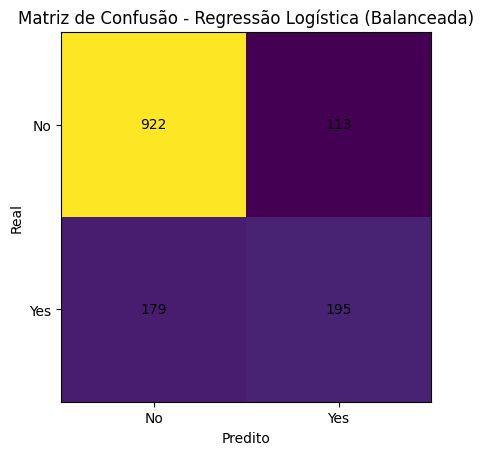

In [ ]:
cm = confusion_matrix(y_teste, y_pred_log_normal)

plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusão - Regressão Logística (Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

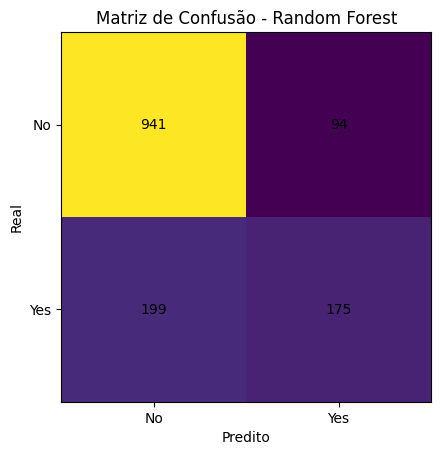

In [ ]:
cm = confusion_matrix(y_teste, y_pred_rf)

plt.figure()
plt.imshow(cm)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

O modelo Random Forest apresentou acurácia de aproximadamente 79%, além de maior precisão na identificação de clientes que cancelam o serviço (65%). No entanto, seu recall foi de 47%, indicando dificuldade em identificar parte dos clientes que realmente realizaram o cancelamento.

Já o modelo Regressão Logística apresentou acurácia também de aproximadamente 79%, com recall ligeiramente superior (52%) para a classe de churn, indicando maior capacidade de identificar clientes que efetivamente cancelaram o serviço. Entretanto, apresentou precisão um pouco menor (63%), gerando mais falsos positivos.

Considerando o equilíbrio entre precisão e recall, a Regressão Logística apresentou F1-score de 0,57, ligeiramente superior ao 0,54 obtido pelo Random Forest, indicando desempenho um pouco melhor na identificação de clientes com risco de cancelamento.



---



#📋  Interpretação e Conclusões

## 🔹 Análise de Importância das Variáveis

In [ ]:
coeficientes = pd.DataFrame({
    "Variável": x_treino.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

coeficientes["Importância"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(by="Importância", ascending=False)

coeficientes.head(10)


,Variável,Coeficiente,Importância
4,Tenure,-1.429277,1.429277
16,ChargesTotal,0.700289,0.700289
20,Contract_Two year,-0.581431,0.581431
17,InternetService_Fiber optic,0.563533,0.563533
18,InternetService_No,-0.509526,0.509526
15,ChargesMonthly,-0.280357,0.280357
19,Contract_One year,-0.279760,0.279760
14,ChargesDaily,-0.238415,0.238415
11,StreamingTV,0.192743,0.192743
6,MultipleLines,0.192132,0.192132


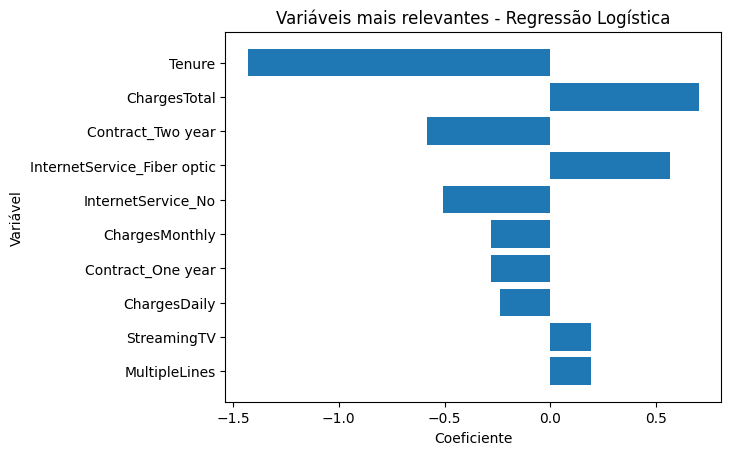

In [ ]:
top_coef = coeficientes.head(10)

plt.figure()
plt.barh(top_coef["Variável"], top_coef["Coeficiente"])
plt.title("Variáveis mais relevantes - Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
importances = modelo_rf.feature_importances_

importancia_rf = pd.DataFrame({
    "Variável": x_treino.columns,
    "Importância": importances
})

importancia_rf = importancia_rf.sort_values(by="Importância", ascending=False)

importancia_rf.head(10)

,Variável,Importância
16,ChargesTotal,0.173267
4,Tenure,0.153174
15,ChargesMonthly,0.143571
14,ChargesDaily,0.117718
17,InternetService_Fiber optic,0.039344
22,PaymentMethod_Electronic check,0.036825
20,Contract_Two year,0.032772
0,Gender,0.025164
13,PaperlessBilling,0.025036
19,Contract_One year,0.024070


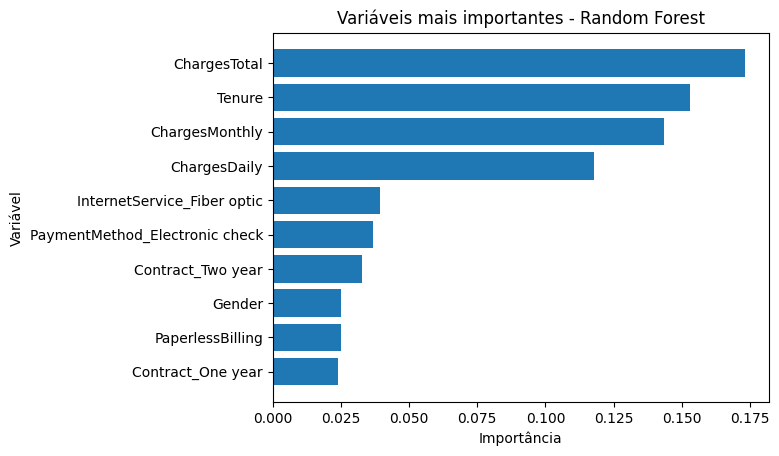

In [ ]:
top_rf = importancia_rf.head(10)

plt.figure()
plt.barh(top_rf["Variável"], top_rf["Importância"])
plt.title("Variáveis mais importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.gca().invert_yaxis()

plt.show()

A análise das variáveis mais relevantes indicou que fatores financeiros e características contratuais possuem forte influência na evasão de clientes. No modelo Random Forest, as variáveis relacionadas aos valores cobrados, como ChargesTotal e ChargesMonthly, além do tempo de relacionamento do cliente (Tenure), apresentaram as maiores importâncias.

Já na Regressão Logística, observou-se que contratos de maior duração, como contratos anuais ou de dois anos, apresentam coeficientes negativos elevados, indicando que reduzem significativamente a probabilidade de churn. Por outro lado, métodos de pagamento como electronic check e o uso de faturamento digital (paperless billing) apresentaram coeficientes positivos, indicando maior probabilidade de cancelamento.

Além disso, a presença de serviços adicionais como suporte técnico e segurança online mostrou impacto negativo na evasão, sugerindo que clientes que utilizam mais serviços da empresa tendem a permanecer por mais tempo.

# ✅ Conclusão

###🔸 Desempenho dos Modelos

Após o treinamento e avaliação dos modelos de **Regressão Logística** e **Random Forest**, foi realizada a análise das variáveis mais relevantes para a previsão de evasão (churn). Essa etapa permite identificar quais características dos clientes possuem maior impacto na probabilidade de cancelamento do serviço.

Os modelos foram avaliados utilizando as métricas acurácia, precisão, recall e F1-score, além da análise das matrizes de confusão.

- O **Random Forest** apresentou maior acurácia e precisão, indicando boa capacidade de identificar corretamente clientes que não cancelam o serviço.
- A **Regressão Logística** balanceada apresentou maior recall, demonstrando melhor capacidade de identificar clientes que realmente cancelam.
- Considerando o equilíbrio entre precisão e recall, a Regressão Logística apresentou melhor F1-score, indicando bom desempenho geral na tarefa de previsão de evasão.

###🔸Principais Fatores que Influenciam o Churn

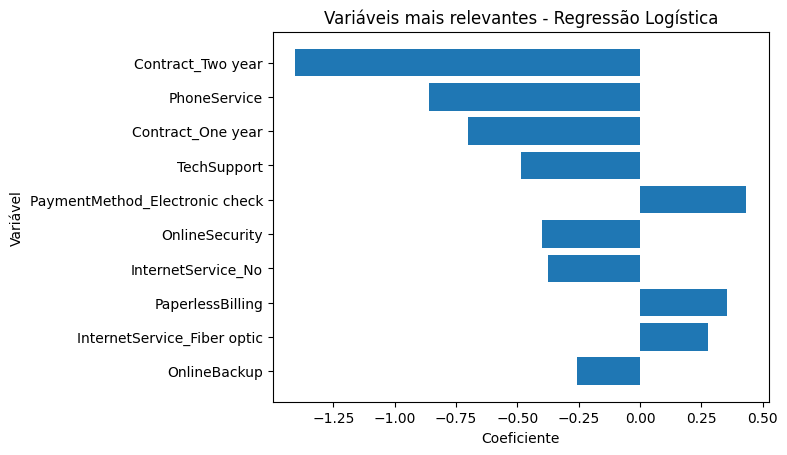

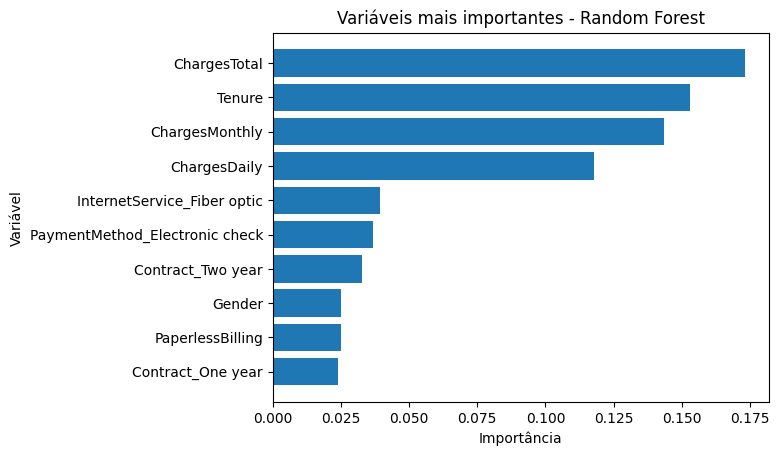

A análise das variáveis mais relevantes indicou que fatores **financeiros, contratuais** e relacionados aos **serviços adicionais** contratados exercem forte influência na evasão de clientes.

1. A análise das variáveis mais relevantes indicou que fatores financeiros, contratuais e relacionados aos serviços contratados exercem forte influência na evasão de clientes.
2. Clientes com contratos mensais apresentam maior probabilidade de cancelamento, enquanto contratos de um ou dois anos reduzem significativamente o risco de churn.
3. O método de pagamento de Cheque Eletrônico apresentou associação positiva com churn na Regressão Logística. Isso indica que clientes que utilizam esse método de pagamento apresentam maior probabilidade de cancelar o serviço, possivelmente por representar clientes com menor fidelização.
4. Serviços adicionais (suporte técnico, segurança online, backuop online, etc.)
apresentaram impacto negativo no churn, indicando que clientes que utilizam mais serviços da empresa tendem a permanecer por mais tempo.

###🔸Estratégias para Retenção de Clientes



1️⃣ Foco nos primeiros meses de contrato:

Como clientes com pouco tempo de contrato apresentam maior risco de cancelamento, recomenda-se:
- Acompanhamento ativo do cliente nos primeiros meses;
- Suporte técnico acessível;
- Benefícios temporários ou testes gratuitos de serviços adicionais

2️⃣ Incentivo a contratos de longo prazo:

Oferecer incentivos para que clientes optem por contratos mais longos, como:
- Incentivos financeiros para migração para planos anuais/bienais;
- Descontos progressivos ou benefícios exclusivos para contratos a longo prazo.

3️⃣ Promoção de serviços adicionais:

Serviços como suporte técnico e segurança online mostraram impacto positivo na retenção. Sendo assim, a empresa pode:
- Oferecer desconto em pacotes de serviços combinados;
- Criar campanhas de adesão aos serviços adicionais nos primeiros meeses de contrato.